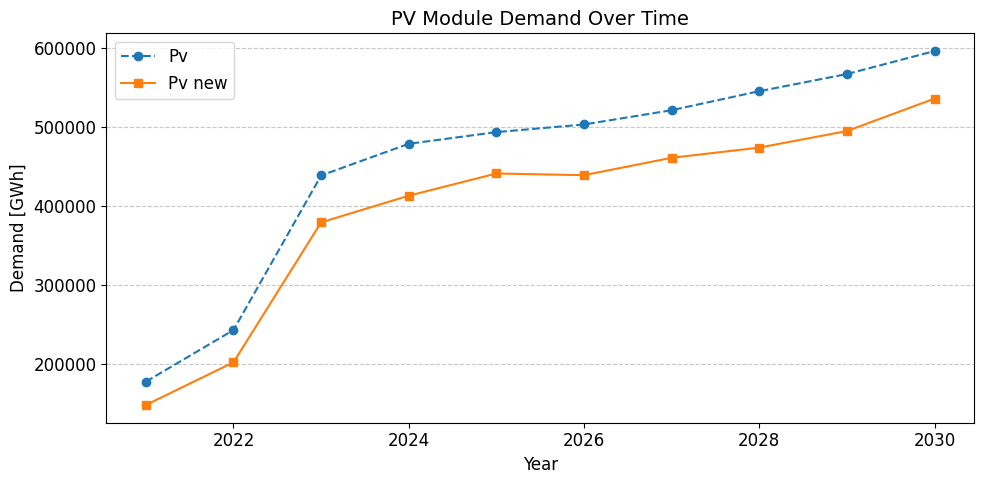

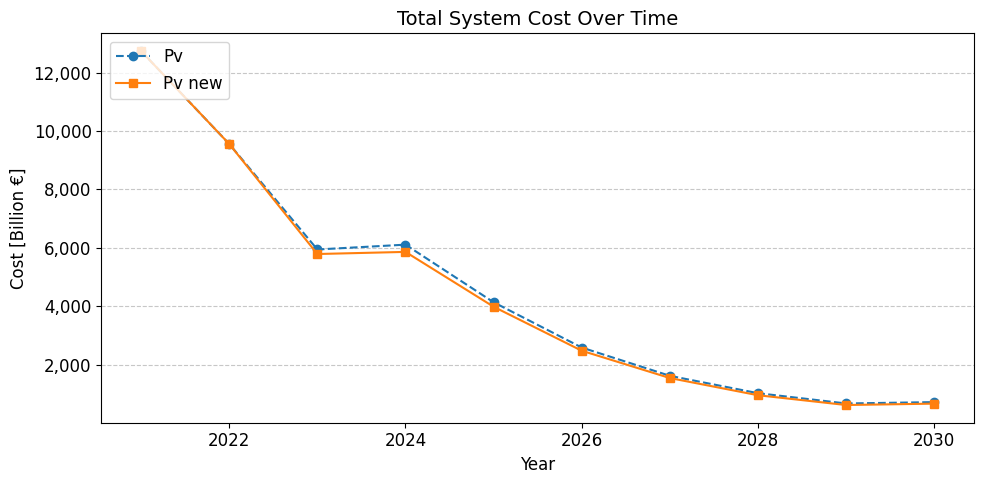

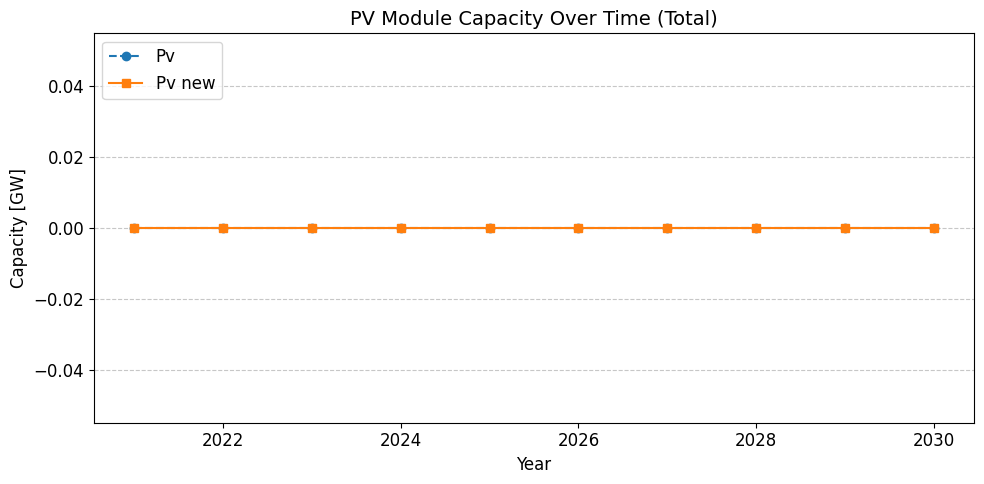

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
base_path = Path("outputs")
datasets = {
    "PV": base_path / "01_SP_MV_PV",
    "PV_new": base_path / "01_SP_MV_PV_new"
}
results = {label: Results(path) for label, path in datasets.items()}

# === Output Save Directory ===
save_path = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\ESM_plots\pv_comparison")
os.makedirs(save_path, exist_ok=True)

# === Plot Config ===
start_year = 2021
plt.rcParams.update({'font.size': 12})

marker_styles = {
    'PV': 'o',
    'PV_new': 's'
}

colors = {
    'PV': '#1f77b4',
    'PV_new': '#ff7f0e'
}

linestyles = {
    'PV': '--',
    'PV_new': '-'
}

line_widths = {
    'PV': 1.5,
    'PV_new': 1.5
}

# === Plot 1: PV Module Demand (Total) ===
try:
    plt.figure(figsize=(10, 5))
    for label, r in results.items():
        df = r.get_full_ts("demand").reset_index()
        df.columns.values[0] = "carrier"
        df_pv = df[df["carrier"] == "pv_module"]
        time_cols = [col for col in df_pv.columns if isinstance(col, (int, float))]
        total = df_pv[time_cols].sum().reset_index()
        total.columns = ["year", "value"]
        total["year"] = total["year"] + start_year

        plt.plot(total["year"], total["value"],
                 marker=marker_styles[label],
                 linestyle=linestyles[label],
                 linewidth=line_widths[label],
                 color=colors[label],
                 label=label.replace("_", " ").capitalize())

    plt.title('PV Module Demand Over Time', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Demand [GWh]')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(save_path / "pv_module_demand.pdf", format='pdf', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Error plotting PV module demand: {e}")

# === Plot 2: Total System Cost ===
try:
    plt.figure(figsize=(10, 5))
    for label, r in results.items():
        df = r.get_full_ts("cost_total").reset_index()
        df["year"] = df["year"] + start_year
        cost_in_beuro = df["value"] * 1e6 / 1e9  # MEUR → EUR → Billion €

        plt.plot(df["year"], cost_in_beuro,
                 marker=marker_styles[label],
                 linestyle=linestyles[label],
                 linewidth=line_widths[label],
                 color=colors[label],
                 label=label.replace("_", " ").capitalize())

    plt.title("Total System Cost Over Time", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Cost [Billion €]")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(save_path / "cost_total.pdf", format='pdf', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Error plotting total system cost: {e}")

# === Plot 3: Total PV Module Capacity (All Locations Combined) ===
try:
    plt.figure(figsize=(10, 5))
    for label, r in results.items():
        df = r.get_full_ts("capacity")

        # Filter to pv_module
        df_pv = df.loc[df.index.get_level_values("technology") == "pv_module"]

        # Time columns as integers
        df_pv.columns = [int(c) if str(c).isdigit() else c for c in df_pv.columns]
        df_pv = df_pv.sort_index(axis=1)

        # Sum over all locations and capacity_types
        total = df_pv.sum().reset_index()
        total.columns = ["year", "value"]
        total["year"] = total["year"] + start_year

        plt.plot(total["year"], total["value"],
                 marker=marker_styles[label],
                 linestyle=linestyles[label],
                 linewidth=line_widths[label],
                 color=colors[label],
                 label=label.replace("_", " ").capitalize())

    plt.title("PV Module Capacity Over Time (Total)", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Capacity [GW]")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(save_path / "pv_module_capacity_total.pdf", format='pdf', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Error plotting total PV module capacity: {e}")

# === Plot 4: PV Module Capacity Per Location ===
try:
    component = "capacity"
    tech = "pv_module"
    level = "location"

    # Get all unique locations from all datasets
    all_locations = set()
    for r in results.values():
        df = r.get_full_ts(component)
        if tech in df.index.get_level_values("technology"):
            locs = df.loc[df.index.get_level_values("technology") == tech].index.get_level_values("location").unique()
            all_locations.update(locs)

    for loc in sorted(all_locations):
        plt.figure(figsize=(10, 5))
        plotted = False

        for label, r in results.items():
            df = r.get_full_ts(component)

            try:
                df_pv = df.xs((tech, "power", loc), level=("technology", "capacity_type", "location"))
            except KeyError:
                continue

            # Ensure time columns are integers
            df_pv.index = [int(i) if str(i).isdigit() else i for i in df_pv.index]
            df_pv = df_pv.sort_index()

            total = df_pv.reset_index()
            total.columns = ["year", "value"]
            total["year"] = total["year"] + start_year

            if total["value"].sum() == 0:
                continue

            plt.plot(total["year"], total["value"],
                     marker=marker_styles[label],
                     linestyle=linestyles[label],
                     linewidth=line_widths[label],
                     color=colors[label],
                     label=label.replace("_", " ").capitalize())
            plotted = True

        if plotted:
            plt.title(f"PV Module Capacity – {loc}", fontsize=14)
            plt.xlabel("Year")
            plt.ylabel("Capacity [GW]")
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.legend(loc='upper left')
            plt.tight_layout()
            filename = f"pv_module_capacity_{loc.lower()}.pdf"
            plt.savefig(save_path / filename, format='pdf', bbox_inches='tight')
            plt.close()
        else:
            plt.close()

except Exception as e:
    print(f"Error plotting PV module capacity per location: {e}")
